In [3]:
import os, sys

import IPython.display as ipd

current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1])
sys.path.append(homepath)
idx = path_parts.index("Nextcloud2")
path = os.sep.join(path_parts[:idx + 1])
path= path+'/phase_retrieval/explore'
sys.path.append(path)


import pandas as pd
import gemmi
import matplotlib.pyplot as plt
import meteor
import reciprocalspaceship as rs
from occupancy import *
from plotting3d import *
%load_ext autoreload 
%autoreload 2

from generate_objects import run_scaleit

# Why this notebook exits
This helped me to figure out that my convention of dealing with mtz files was not compatible with rsmap.
Conclusion: Only use rsmap.

In [ ]:
folderloc =  homepath+'/../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

# Overview over data

In [5]:
ds_dark.head()

I-obs      SIGI-obs  R-free-flags  F-obs-filtered  \
H K L                                                              
0 0 6   284157.84375  28358.560547             6     3381.124023   
    8     114.540741     38.163765            17       67.087746   
    10   4017.811523    139.221115             8      421.545776   
    12  46658.433594   1461.593262            11     1435.483765   
    14   1479.636963     58.852287             0      255.786545   

        SIGF-obs-filtered      F-model  PHIF-model      2FOFCWT  PH2FOFCWT  \
H K L                                                                        
0 0 6          186.983047  3328.107178         0.0  3773.437256        0.0   
    8           14.345318     8.001706         0.0     0.535461        0.0   
    10           7.316233   441.704254         0.0   471.327728        0.0   
    12          22.552881  1184.225586       180.0  1559.282227      180.0   
    14           5.098086   183.673569       180.0     154.3396      180.0   

        2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H K L                                                             
0 0 6       3773.437256                0.0   79.419266       0.0  
    8          0.535461                0.0    8.313123     180.0  
    10       471.327728                0.0   26.647619     180.0  
    12      1559.282227              180.0  279.940491     180.0  
    14         154.3396              180.0   43.214062       0.0

In [6]:
ds_light.head() 

IMEAN       SIGIMEAN           F       SIGF       KFEXTR  \
H K L                                                                   
0 0 2          NaN            NaN         NaN        NaN          NaN   
    4          NaN            NaN         NaN        NaN          NaN   
    6   563041.625  124030.234375  733.373047  87.899185  3107.084473   
    7 -1661.612183    1027.905151    12.38824   8.876429          NaN   
    8  -470.827209     346.035034    7.571723   5.376757    58.114021   

       SIGKFEXTR  R-free-flags      F-model  PHIF-model      2FOFCWT  \
H K L                                                                  
0 0 2        NaN           NaN          NaN         NaN  6650.478516   
    4        NaN            14          NaN         NaN  1927.483765   
    6  16.496628             6  3358.235596         0.0  3301.962158   
    7        NaN           NaN          NaN         NaN          NaN   
    8  40.554333            17   168.217529         0.0     2.425961   

       PH2FOFCWT  2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H K L                                                                       
0 0 2        0.0              NaN                NaN         NaN       NaN  
    4        0.0              NaN                NaN         NaN       NaN  
    6        0.0      3301.962158                0.0  752.040527       0.0  
    7        NaN              NaN                NaN         NaN       NaN  
    8        0.0         2.425961                0.0  124.879761     180.0

In [7]:
# # dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
# dataloc_light = "../photolyase_masks/8oy8.mtz"
# ds_light = rs.read_mtz(dataloc_light)
# ds_light.head()

In [8]:
names_dict = {
    # "photolyase10": "Photolyase 10 ns", 
    "photolyase30": "Photolyase 30 ns", 
    # "synthetic_cistrans": "rsEGFP2 (synth)",
    # "real_cistrans": "rsEGFP2 (meteor)",
    # "mpro": "MPRO (meteor)",
    # "doeke": "EFX protein (Doeke)",
}
import reciprocalspaceship as rs
def struc2realspace(struc, hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F","PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    # struc_vals_real = struc_vals.transform_f_phi_to_map("sf")

    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real

from generate_objects import get_pdb_pairs
for name in names_dict.keys():    
    pdb_pair = get_pdb_pairs(name)
    parent = "/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/"
    fname_dark = f"{parent}synthetic_data/{pdb_pair[0]}.pdb"
    fname_mix = f"{parent}synthetic_data/{pdb_pair[1]}.pdb"
    struc_dark = gemmi.read_structure(fname_dark)
    struc_light = gemmi.read_structure(fname_mix)
    density_darkT = struc2realspace(struc_dark, 1.2, 0)
    density_lightT = struc2realspace(struc_light, 1.2, 0)
print(density_darkT.shape)
print(density_lightT.shape)
unit = np.array((
    struc_dark.cell.a,
    struc_dark.cell.b,
    struc_dark.cell.c
))

(180, 300, 432)
(180, 300, 432)


In [9]:
def get_pdb_pos(pdbname):
    st = gemmi.read_structure(pdbname)
    st.remove_alternative_conformations()
    st.remove_hydrogens()
    st.remove_waters()
    st.remove_ligands_and_waters()
    st.remove_empty_chains()
    pos_list = np.array([st.cell.fractionalize(rca.atom.pos).tolist()   for rca in st[0].all()])
    print((st.spacegroup_hm))
    print((st.cell.is_compatible_with_spacegroup(gemmi.SpaceGroup("P 1"))))
    st.setup_cell_images()
    # print(st.find_nearest
    st.setup_cell_images()
    pos_list = np.array([st.cell.fractionalize(rca.atom.pos).tolist()   for rca in st[0].all()])
    print(len(st))
    return pos_list

In [10]:
struc_dark = gemmi.read_structure(fname_dark)
pos_list =get_pdb_pos(fname_dark)

dataloc_light = homepath+"/../photolyase_masks/8oy8.mtz"
mtz_dark = gemmi.read_mtz_file(dataloc_dark)
mtz_light = gemmi.read_mtz_file(dataloc_light)
size = mtz_dark.get_size_for_hkl(sample_rate=1.2)

fouplex_dark = mtz_dark.get_f_phi_on_grid('F-model', "PHIF-model",size)
fouplex_light = mtz_light.get_f_phi_on_grid('FC', "PHIC",size)
def get_real(fouplex):
    fouplex = np.array(fouplex)
    mask = np.isfinite(fouplex)
    fouplex[~mask] = 0
    return np.fft.ifftn(fouplex).real 
realplex_dark = get_real(fouplex_dark)
realplex_light = get_real(fouplex_light)
protein_shape = realplex_dark.shape
frac_mask, frac_list = np.divmod(pos_list, 1)
# d2_points, d2_mask = make_points(frac_list, 0, imlen, frac_mask)
sizes = np.array(protein_shape)[[2,1,0]]
pos2 = pos_list[:,[2,1,0]]


P 21 21 21
True
1


In [11]:
print(realplex_dark.shape , realplex_light.shape )


(120, 200, 288) (120, 200, 288)


In [12]:
# pos_trans = pos2[:,[2,1,0]]
# unwrap_trans = unwrap_v2[[2,1,0]].transpose(0,3,2,1)
# print(motif.shape,motif.transpose(2,1,0).shape,
#     unwrap_v2.shape,unwrap_trans.shape)
from output_eval import mtz_comp
%matplotlib widget
pos2 = pos_list[:,[1,0,2]]
# _ = mtz_comp(pos2,map_density)

In [13]:
dark_f = 'F-model'
dark_phi = "PHIF-model"

# dark_f = 'F'
# dark_phi = "PHI"
# dark_phi = "PHI"
from meteor import rsmap
map_dark = rsmap.Map.read_mtz_file(
    dataloc_dark,
    amplitude_column=dark_f,
    phase_column=dark_phi,
    # uncertainty_column=dark_sigma,
)
map_density = map_dark.to_3d_numpy_map(map_sampling=1.2)

In [14]:
dataloc_dark

'/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../photolyase_share_reviewers/1_superdark/superdark_deposit.mtz'

In [15]:
map_density.shape
realplex_light.shape

(120, 200, 288)

interactive(children=(IntSlider(value=60, description='f0', max=119), Output()), _dom_classes=('widget-interac…

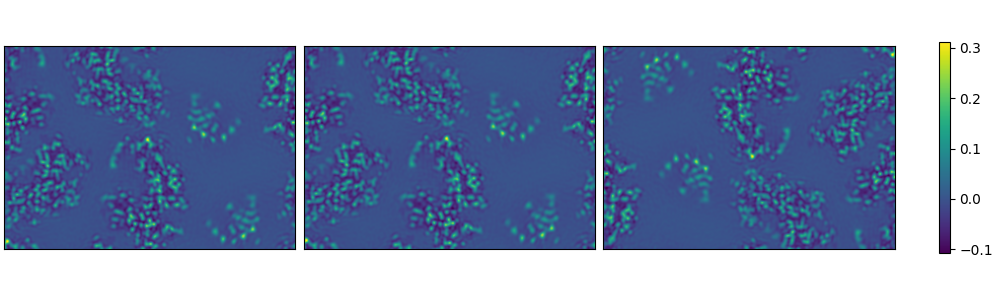

(<Figure size 1000x300 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

In [16]:
from output_eval import panels_3d 
panels_3d((map_density,
          realplex_dark[:,::-1,::-1], 
           # realplex_light,
          realplex_dark, 
          ),figkwargs={"figsize":(10,3)})

120
(-0.001736111111111111, 0.9982638888888888, 0.9975, -0.0025)


interactive(children=(IntSlider(value=0, description='f0', max=119), Output()), _dom_classes=('widget-interact…

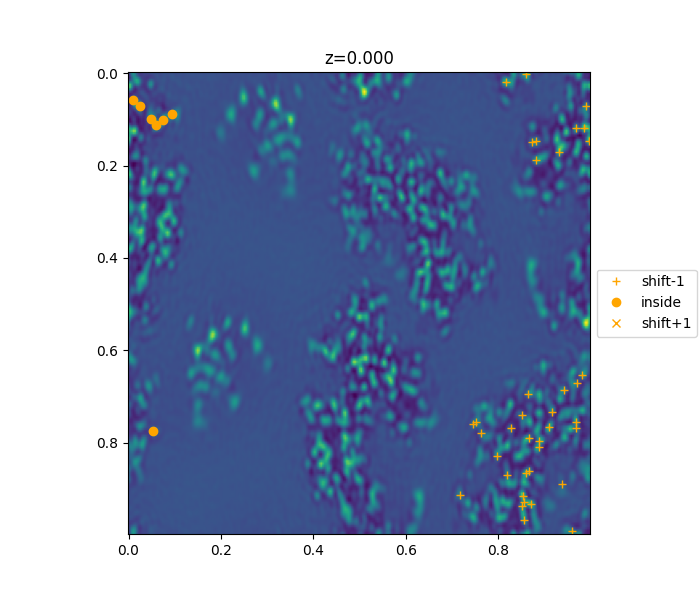

In [17]:
_ = mtz_comp(pos_list,map_density, )

120
(-0.001736111111111111, 0.9982638888888888, 0.9975, -0.0025)


interactive(children=(IntSlider(value=0, description='f0', max=119), Output()), _dom_classes=('widget-interact…

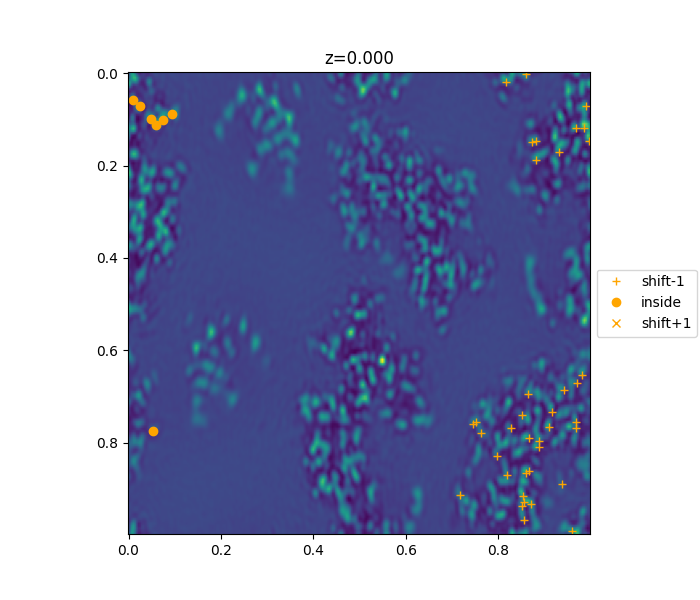

In [18]:
_ = mtz_comp(pos_list,realplex_dark[::-1,::-1,::-1], )


In [19]:
def write_mtz(data_array, fname, rsdf, hs_limit):
    print('did you check orientation')
    mapobj = rsmap.Map.from_3d_numpy_map(data_array, 
                                         spacegroup=rsdf.spacegroup,
                                         cell =rsdf.cell, 
                                         high_resolution_limit=hs_limit)
    mapobj.write_mtz(fname)

write_mtz(map_density, "test_1.mtz", ds_light, 1.2)
write_mtz(realplex_dark[::-1,::-1,::-1], "test_2.mtz", ds_light, 1.2)

did you check orientation
did you check orientation


In [20]:
(np.max(map_density),np.max(realplex_dark),
np.max(map_density)/np.max(realplex_dark),
np.min(map_density)/np.min(realplex_dark)
)

(2.7210813, 0.5547798883747026, 4.9047943407577455, 4.904795553656693)

In [21]:
def get_real(fouplex):
    fouplex = np.array(fouplex)
    mask = np.isfinite(fouplex)
    fouplex[~mask] = 0
    return np.fft.fftn(fouplex).real 
realplex_dark_v2 = get_real(fouplex_dark)


interactive(children=(IntSlider(value=0, description='f0', max=119), Output()), _dom_classes=('widget-interact…

7.096058382026468e-07


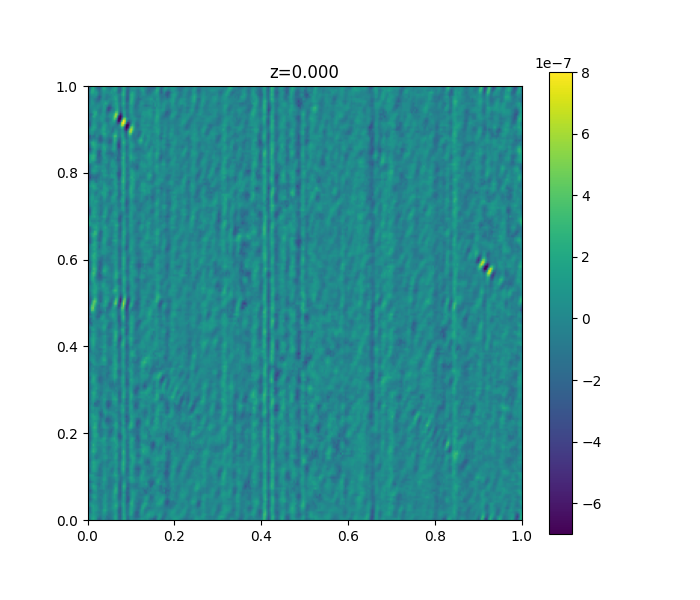

In [22]:
offset = 1
slc = slice(offset,None)
bot_slc = (slc,slc,slc)
slc = slice(None,-offset,-1)
top_slc = (slc,slc,slc)

rpd = realplex_dark[::-1,::-1,::-1,][:-offset,:-offset,:-offset,]
scaling = np.min(map_density)/np.min(realplex_dark)

# _ = slice_3d(map_density[bot_slc] - rpd*scaling)

rpd = realplex_dark_v2#[::-1,::-1,::-1,]#[:-offset,:-offset,:-offset,]
scaling = np.min(map_density)/np.min(realplex_dark_v2)
_ = slice_3d(map_density - rpd*scaling)
print(scaling)